<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula15c_semi_supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import load_digits
X, y = load_digits(return_X_y=True)

X_train, X_test, y_train, y_test = X[:1400], X[1400:], y[:1400], y[1400:]
print(X_train.shape)
print(X_test.shape)

(1400, 64)
(397, 64)


In [3]:
y[:50]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1,
       2, 3, 4, 5, 6, 7, 8, 9, 0, 9, 5, 5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7,
       7, 3, 5, 1, 0, 0])

In [4]:
from sklearn.linear_model import LogisticRegression

n_labeled = 50
log_reg = LogisticRegression()
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])
log_reg.score(X_test, y_test)

0.7581863979848866

In [7]:
log_reg_full = LogisticRegression(tol=1e-3)
log_reg_full.fit(X_train, y_train)
log_reg_full.score(X_test, y_test)

0.9118387909319899

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=n_labeled)
X_digit_dist = kmeans.fit_transform(X_train)
print(X_digit_dist.shape)

(1400, 50)


In [9]:
import numpy as np

representative_digit_idx = np.argmin(X_digit_dist, axis=0)
X_representative_digits = X_train[representative_digit_idx]

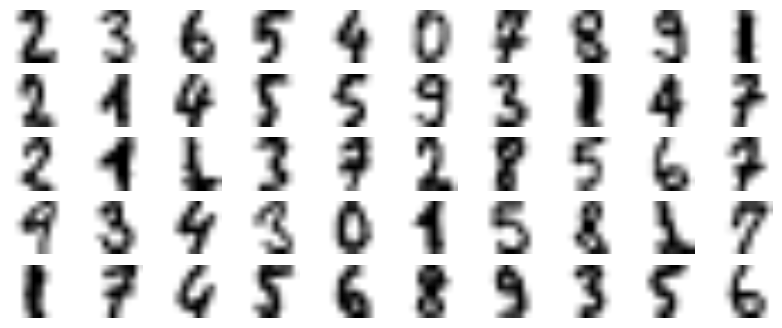

In [10]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 4))
for i in range(n_labeled):
  plt.subplot(n_labeled//10, 10, i + 1)
  plt.imshow(X_representative_digits[i].reshape(8, 8), cmap="gray_r", interpolation="bilinear")
  plt.axis('off')
plt.show()

In [12]:
y_representative = y_train[representative_digit_idx]
for i in range(n_labeled//10):
  print(y_representative[i*10:(i+1)*10])

[2 3 6 5 4 0 7 8 9 1]
[2 1 4 5 5 9 3 1 4 7]
[2 1 1 3 7 2 8 5 6 7]
[9 3 4 3 0 1 5 8 1 7]
[1 7 4 5 6 8 9 3 5 6]


In [13]:
log_reg_representative = LogisticRegression(tol=1e-3)
log_reg_representative.fit(X_representative_digits, y_representative)
log_reg_representative.score(X_test, y_test)

0.8287153652392947

In [14]:
y_train_propagated = np.empty(X_train.shape[0])
for i in range(n_labeled):
  y_train_propagated[kmeans.labels_==i] = y_representative[i]
log_reg_propagated = LogisticRegression(tol=1e-3)
log_reg_propagated.fit(X_train, y_train_propagated)
log_reg_propagated.score(X_test, y_test)

0.8866498740554156

In [16]:
print((y_train_propagated == y_train).mean())

0.9521428571428572
